In [ ]:
import pandas as pd
import re
from sentence_transformers import SentenceTransformer, util
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Final_df.csv')

In [ ]:
df.head()

,Question,Response_Number,Response,Score,Answer
0,What is data science?,R1,Data science is a field that combines statisti...,1.00,Data science is an interdisciplinary field tha...
1,What are the key steps in the data science pro...,R1,The key steps in the data science process incl...,0.95,The key steps typically include problem defini...
2,What is the difference between supervised and ...,R1,Supervised learning uses labeled data to train...,1.00,Supervised learning involves training a model ...
3,Explain the bias-variance tradeoff.,R1,The bias-variance tradeoff is a concept in mac...,1.00,The bias-variance tradeoff is the balance betw...
4,What is feature engineering?,R1,Feature engineering is the process of creating...,1.00,Feature engineering is the process of selectin...


In [ ]:
df = df[['Question', 'Answer', 'Response', 'Score']]

In [ ]:
df.head()

,Question,Answer,Response,Score
0,What is data science?,Data science is an interdisciplinary field tha...,Data science is a field that combines statisti...,1.00
1,What are the key steps in the data science pro...,The key steps typically include problem defini...,The key steps in the data science process incl...,0.95
2,What is the difference between supervised and ...,Supervised learning involves training a model ...,Supervised learning uses labeled data to train...,1.00
3,Explain the bias-variance tradeoff.,The bias-variance tradeoff is the balance betw...,The bias-variance tradeoff is a concept in mac...,1.00
4,What is feature engineering?,Feature engineering is the process of selectin...,Feature engineering is the process of creating...,1.00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2620 entries, 0 to 2619
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Question  2620 non-null   object 
 1   Answer    2620 non-null   object 
 2   Response  2620 non-null   object 
 3   Score     2620 non-null   float64
dtypes: float64(1), object(3)
memory usage: 82.0+ KB


## Stripping Extra White Spaces

In [ ]:
df['Answer'] = df['Answer'].str.strip()
df['Response'] = df['Response'].str.strip()

## Lower Casing

In [ ]:
df['Answer'] = df['Answer'].str.lower()
df['Response'] = df['Response'].str.lower()

## Removing HTML Tags and Special Characters

In [ ]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)  # remove HTML tags
    text = re.sub(r'[^A-Za-z0-9\s.,?!\'"]', '', text)  # keep common punctuation
    return text

df['Answer'] = df['Answer'].apply(clean_text)
df['Response'] = df['Response'].apply(clean_text)

In [ ]:
df.head()

,Question,Answer,Response,Score
0,What is data science?,data science is an interdisciplinary field tha...,data science is a field that combines statisti...,1.00
1,What are the key steps in the data science pro...,the key steps typically include problem defini...,the key steps in the data science process incl...,0.95
2,What is the difference between supervised and ...,supervised learning involves training a model ...,supervised learning uses labeled data to train...,1.00
3,Explain the bias-variance tradeoff.,the biasvariance tradeoff is the balance betwe...,the biasvariance tradeoff is a concept in mach...,1.00
4,What is feature engineering?,feature engineering is the process of selectin...,feature engineering is the process of creating...,1.00


## Duplicate and Normalize Data Science Terms

In [ ]:
def normalize_data_science_terms(text):
    replacements = {
        "ml": "machine learning",
        "ai": "artificial intelligence",
        "dl": "deep learning",
        "nlp": "natural language processing",
        "cv": "computer vision",
        "eda": "exploratory data analysis",
        "svm": "support vector machine",
        "cnn": "convolutional neural network",
        "rnn": "recurrent neural network",
        "ann": "artificial neural network",
        "lstm": "long short term memory",
        "xgboost": "extreme gradient boosting",
        "gbm": "gradient boosting machine",
        "knn": "k nearest neighbors",
        "lr": "logistic regression",
        "regression model": "regression",
        "classification model": "classification",
        "scikit-learn": "sklearn",
        "sci-kit learn": "sklearn",
        "tf": "tensorflow",
        "pytorch": "torch",
        "feature engineering": "feature extraction",
        "data wrangling": "data cleaning",
        "data visualization": "data viz",
        "viz": "visualization"
    }
    text = text.lower()
    for key, val in replacements.items():
        text = text.replace(key, val)
    return text

In [ ]:
df['Answer'] = df['Answer'].apply(normalize_data_science_terms)
df['Response'] = df['Response'].apply(normalize_data_science_terms)

# Semantic Similarity

In [ ]:
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Encoding Answers and Responses

In [ ]:
answer_embeddings = semantic_model.encode(df['Answer'].tolist(), convert_to_tensor=True)
response_embeddings = semantic_model.encode(df['Response'].tolist(), convert_to_tensor=True)

## Compute Cosine Similarity

In [ ]:
cosine_scores = util.cos_sim(answer_embeddings, response_embeddings)

In [ ]:
df['semantic_similarity'] = torch.diag(cosine_scores).tolist()

In [ ]:
df.head()

,Question,Answer,Response,Score,semantic_similarity
0,What is data science?,data science is an interdisciplinary field tha...,data science is a field that combines statisti...,1.00,0.866848
1,What are the key steps in the data science pro...,the key steps typically include problem defini...,the key steps in the data science process incl...,0.95,0.651658
2,What is the difference between supervised and ...,supervised learning involves trartificial inte...,supervised learning uses labeled data to trart...,1.00,0.915449
3,Explain the bias-variance tradeoff.,the biasvariance tradeoff is the balance betwe...,the biasvariance tradeoff is a concept in mach...,1.00,0.915531
4,What is feature engineering?,feature extraction is the process of selecting...,feature extraction is the process of creating ...,1.00,0.875637


In [ ]:
df.tail()

,Question,Answer,Response,Score,semantic_similarity
2615,What are the common density estimation techniq...,common techniques include histogrambased metho...,decision trees are commonly used density estim...,0.1,0.597383
2616,What is the Gaussian Mixture Model (GMM)?,gaussian mixture model gmm is a probabilistic ...,gmm is faster than kmeans because it uses fewe...,0.4,0.401086
2617,What is the Expectation-Maximization (EM) algo...,the expectationmaximization em algorithm is an...,em is especially useful when direct optimizati...,1.0,0.627378
2618,What is the difference between generative and ...,generative models learn the joint probability ...,the martificial intelligencen difference is th...,0.3,0.639115
2619,What is the purpose of generative modeling?,generative modeling is used to model the under...,generative modeling focuses on discriminating ...,0.2,0.724393


## Plotting Semantic Scores against Scores

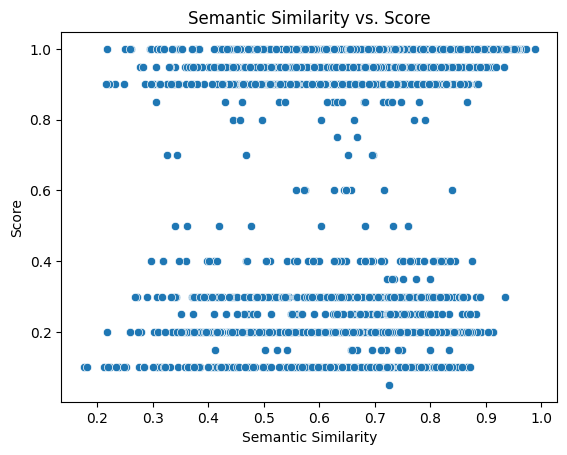

In [ ]:
sns.scatterplot(x='semantic_similarity', y='Score', data=df)
plt.title('Semantic Similarity vs. Score')
plt.xlabel('Semantic Similarity')
plt.ylabel('Score')
plt.show()

In [ ]:
semantic_scores = df['semantic_similarity']

In [ ]:
semantic_scores

,semantic_similarity
0,0.866848
1,0.651658
2,0.915449
3,0.915531
4,0.875637
...,...
2615,0.597383
2616,0.401086
2617,0.627378
2618,0.639115


In [ ]:
from scipy.stats import pearsonr, spearmanr

# Pearson correlation
pearson = pearsonr(df['Score'], df['semantic_similarity'])[0]

# Spearman correlation
spearman = spearmanr(df['Score'], df['semantic_similarity'])[0]


print("Model - Pearson:", pearson, "Spearman:", spearman)

Model - Pearson: 0.16441083516056643 Spearman: 0.21187909833271382


In [ ]:
semantic_scores.to_csv('Semantic_scores.csv',index=False)